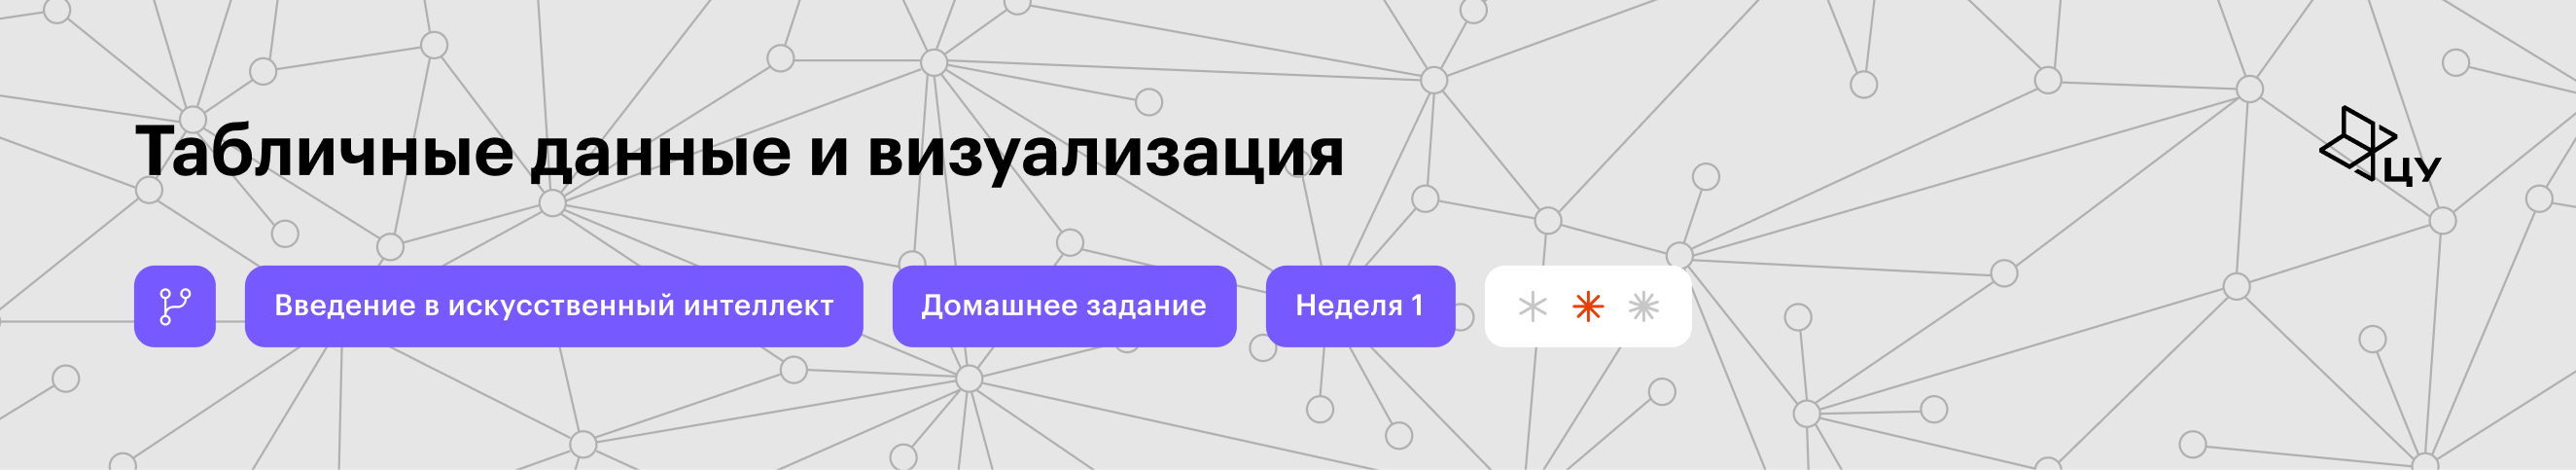

# Домашнее задание по теме «Табличные данные и визуализация»

В этом задании ты изучишь датасет Student Depression. Надеемся, что выводы, которые ты сделаешь после анализа датасета, пригодятся в реальной жизни!

> **Этическая оговорка.** Это учебные наблюдательные данные. Целевая метка `Depression` не является медицинским диагнозом, найденные связи не доказывают причинность, а результаты анализа не предназначены для медицинских решений.

Обрати внимание, что около каждой задачи указано количество баллов, которое можно получить за её выполнение.



> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.


## Установка библиотек

In [107]:
%pip install -q seaborn gdown

/home/igor/dev/competitive-py/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [108]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Задание 1. Линейная регрессия через производные [2 балла]

Рассмотрим маленький датасет с двумя признаками и целевой переменной:

| Объект | $x_1$ | $x_2$ | $y$ |
|:--:|--:|--:|--:|
| 1 | $-2$ | $1$ | $4$ |
| 2 | $2$ | $1$ | $10$ |
| 3 | $1$ | $-1$ | $9$ |
| 4 | $-1$ | $-1$ | $1$ |

Будем строить линейную модель

$$
\hat y=b+w_1x_1+w_2x_2.
$$

Функция потерь для четырёх объектов имеет вид

$$
MSE(b,w_1,w_2)=\frac14\sum_{i=1}^{4}(\hat y_i-y_i)^2.
$$

Найди параметры модели вручную.

1. Подставь значения всех четырёх объектов и выпиши MSE как явную функцию от $b$, $w_1$, $w_2$ **[0,5 балла]**.
2. Найди три частные производные: $\frac{\partial MSE}{\partial b}$, $\frac{\partial MSE}{\partial w_1}$ и $\frac{\partial MSE}{\partial w_2}$ **[0,5 балла]**.
3. Приравняй все три производные к нулю, реши получившуюся систему уравнений и найди $b$, $w_1$, $w_2$ **[0,4 балла]**.
4. Вручную найди прогноз модели для каждого объекта **[0,2 балла]**.
5. Посчитай MSE и MAE получившейся модели **[0,4 балла]**:

$$
MAE=\frac14\sum_{i=1}^{4}|\hat y_i-y_i|.
$$

> Это полностью письменное задание. Нельзя использовать матричную запись, `np.linalg`, готовые модели машинного обучения и численные оптимизаторы. Все производные и промежуточные вычисления приведи вручную в следующей markdown-ячейке. Код в задании 1 писать не нужно.


### Ручные вычисления

Выпиши здесь MSE после подстановки данных, три частные производные, систему уравнений, найденные коэффициенты, прогнозы и обе метрики.

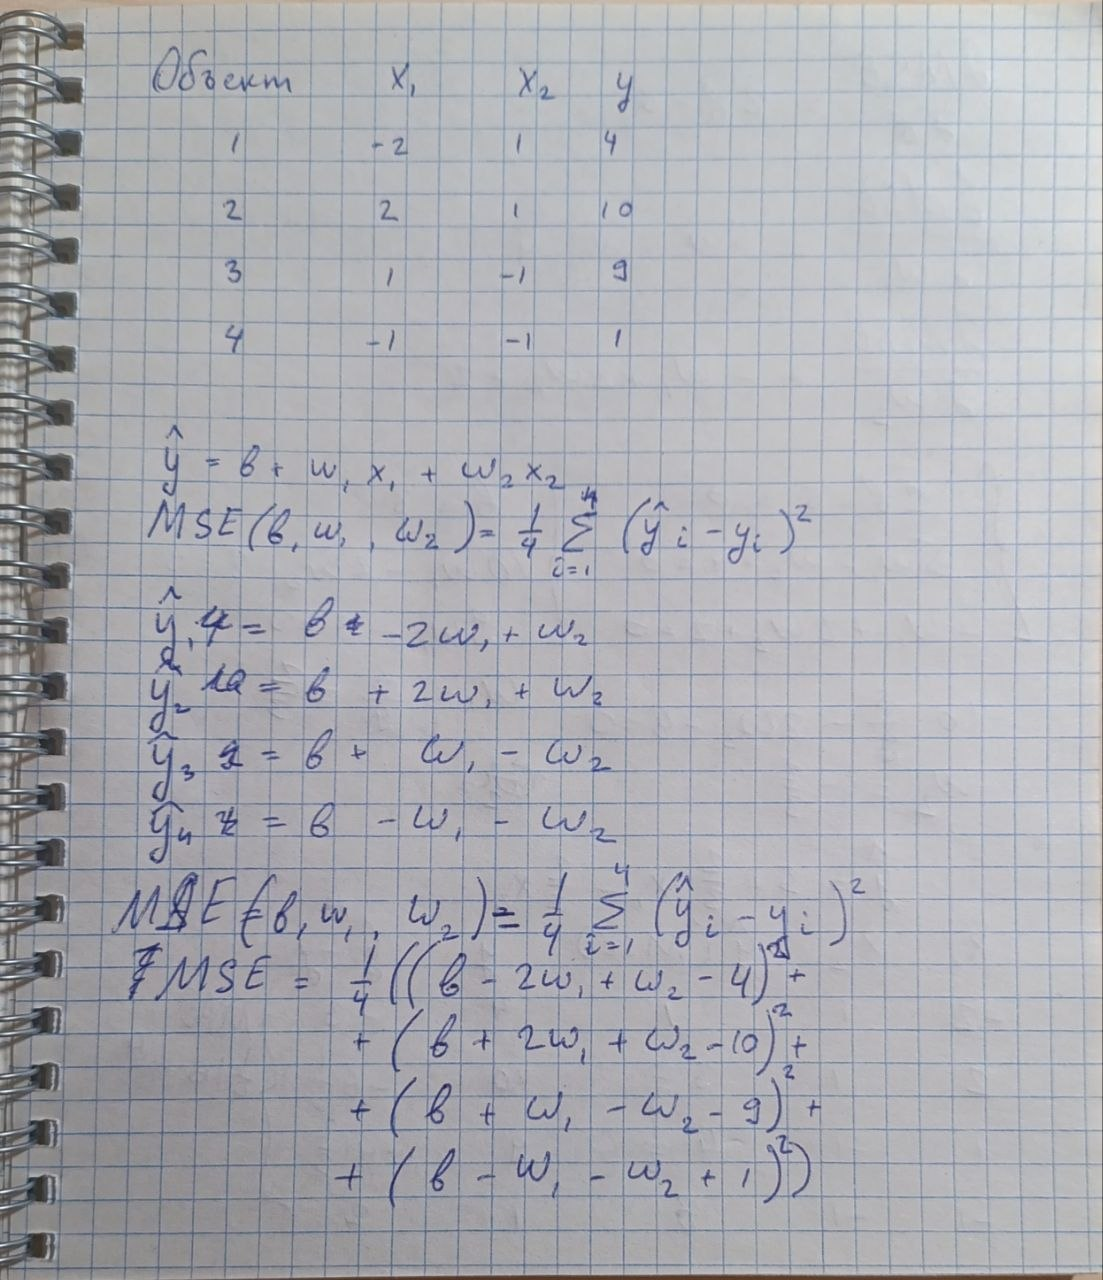

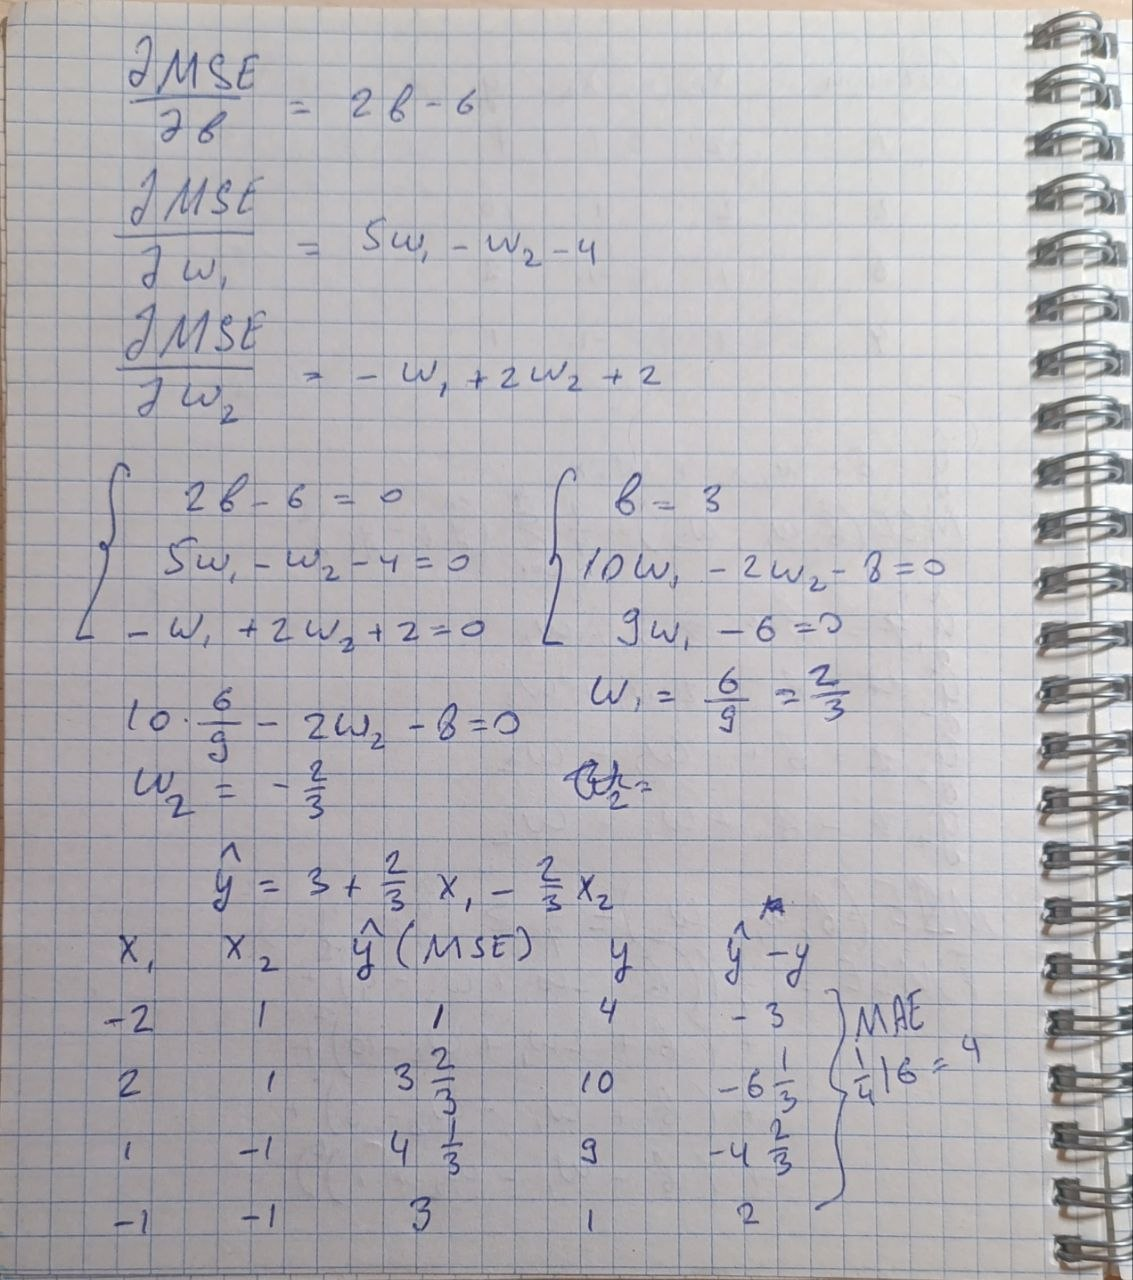

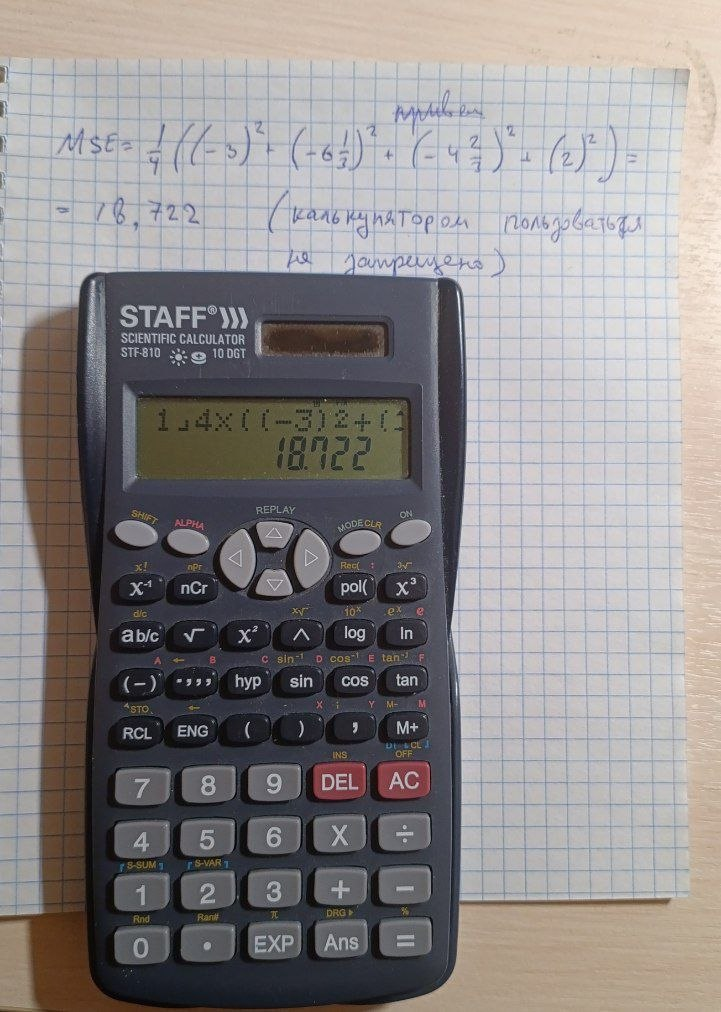

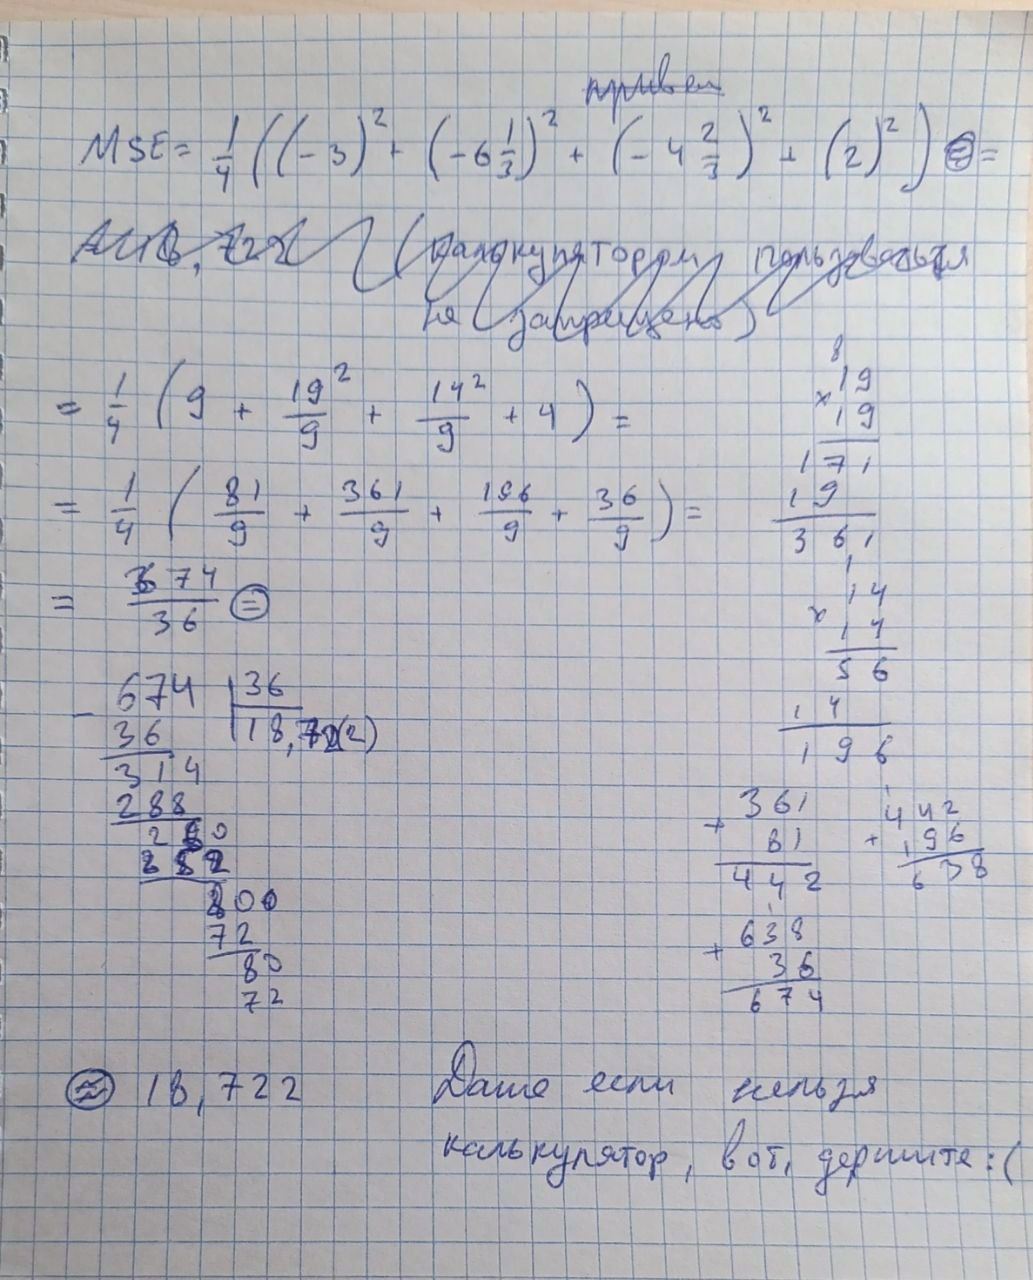

## Задание 2 [1 балл]

Необходимые данные хранятся по [ссылке](https://drive.google.com/file/d/1NiF28k5POrZsofchU6k0X1AR3OCVJl4s/view?usp=drive_link). Загрузи их в ноутбук.

1. Воспользуйся библиотекой `gdown` для загрузки данных **[0 баллов]**.
2. Считай датасет в pandas dataframe **[0,2 балла]**.
3. Выведи датасет на экран **[0,3 балла]**.
4. Исключи переменную `id` или сделай её индексом. Можешь выбрать любой вариант **[0,5 балла]**.

In [109]:
# 1. Загрузи файл
import gdown

gdown.download(
    id="1NiF28k5POrZsofchU6k0X1AR3OCVJl4s",
    output="Student Depression Dataset.csv",
    quiet=False,
)

Downloading...
From: https://drive.google.com/uc?id=1NiF28k5POrZsofchU6k0X1AR3OCVJl4s
To: /mnt/HDD-XFS/dev/competitive-py/Student Depression Dataset.csv
100%|██████████| 2.81M/2.81M [00:00<00:00, 4.50MB/s]


'Student Depression Dataset.csv'

In [110]:
# 2. Считай датасет
df = pd.read_csv("Student Depression Dataset.csv")

In [111]:
# 3. Вывод датасета

# Напиши код здесь
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [112]:
# 4. Преобразуй переменную id

# Напиши код здесь
df.set_index("id", inplace=True)
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
id,,,,,,,,,,,,,,,,,
2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## Задание 3 [2 балла]

Проведи первичный анализ данных.

1. Выведи информацию по типам данных каждой колонки **[0,25 балла]**.
2. Выведи информацию по NaN-значениям. Если они есть, напиши, как их можно заполнить **[0,25 балла]**.
3. Построй описательные статистики для числовых переменных (максимальное и минимальное значение, среднее) и напиши по ним выводы **[0,75 балла]**.
4. Сделай описательные статистики для нечисловых переменных (количество уникальных элементов, наиболее популярный представитель) **[0,75 балла]**.

В пунктах 3–4 тебе может помочь [документация](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).

In [113]:
# 1. Вывод информации о типах данных

# Напиши код здесь
df.info()

<class 'pandas.DataFrame'>
Index: 27901 entries, 2 to 140699
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  str    
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  str    
 3   Profession                             27901 non-null  str    
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  str    
 10  Dietary Habits                         27901 non-null  str    
 11  Degree           

In [114]:
# 2. Вывод информации о NaN

# Напиши код здесь
# ну как будто df.info() выдал информацию о Non-Null, из этого легко получить Nan
# ну или вот таким вот вариантом
df.isna().sum()

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

**Анализ NaN-значений**

Твой комментарий о NaN-ах.


честно, не понмаю какой комментанрий стоит дать, но ну типо ну нет данных у 3х человек по их финансовой нагрузке
мб это произошло потому что их опросили без этих вопросов, а потом опросник дополнили


In [115]:
# 3. Описательная статистика числовых переменных

# Напиши код здесь
df.describe(include=['number'])

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


Напиши выводы по описательной статистике числовых переменных.



In [116]:
# 4. Описательная статистика нечисловых переменных

# Напиши код здесь

# в семинаре был df.describe(include='object'), но это уже устарело, линтер говорит вот так правильнее писать
df.describe(exclude=['number'])

,Gender,City,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
count,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,14,5,4,28,2,2
top,Male,Kalyan,Student,Less than 5 hours,Unhealthy,Class 12,Yes,No
freq,15547,1570,27870,8310,10317,6080,17656,14398


Напиши выводы по описательной статистике нечисловых переменных.

в основном респонденты студенты(class 12), спят меньше 5 часов, нездорово питаются, слышали про суицид, но далеко не у всех родственники самоубивались

## Задание 4 [2 балла]

Проведи разведочный анализ данных.

### Шаг 1 [1 балл]
Построй распределение целевой переменной `Depression` и распределения числовых признаков **[0,25 балла]**.

Проанализируй полученные графики **[0,75 балла]**.

Подробно разберись минимум с двумя числовыми признаками и ответь на следующие вопросы.

1) Какое распределение у признака, и почему оно именно такое?

2) Есть ли выбросы? Чем они могут быть вызваны?

In [117]:
# Напиши код здесь
number_columns = df.select_dtypes(include="number").columns.tolist()
print("колонки с числовыми значениями:", len(number_columns), number_columns)
non_number_columns = df.select_dtypes(exclude="number").columns.tolist()
print("колонки с не числовыми значениями:", len(non_number_columns), non_number_columns)


колонки с числовыми значениями: 9 ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']
колонки с не числовыми значениями: 8 ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


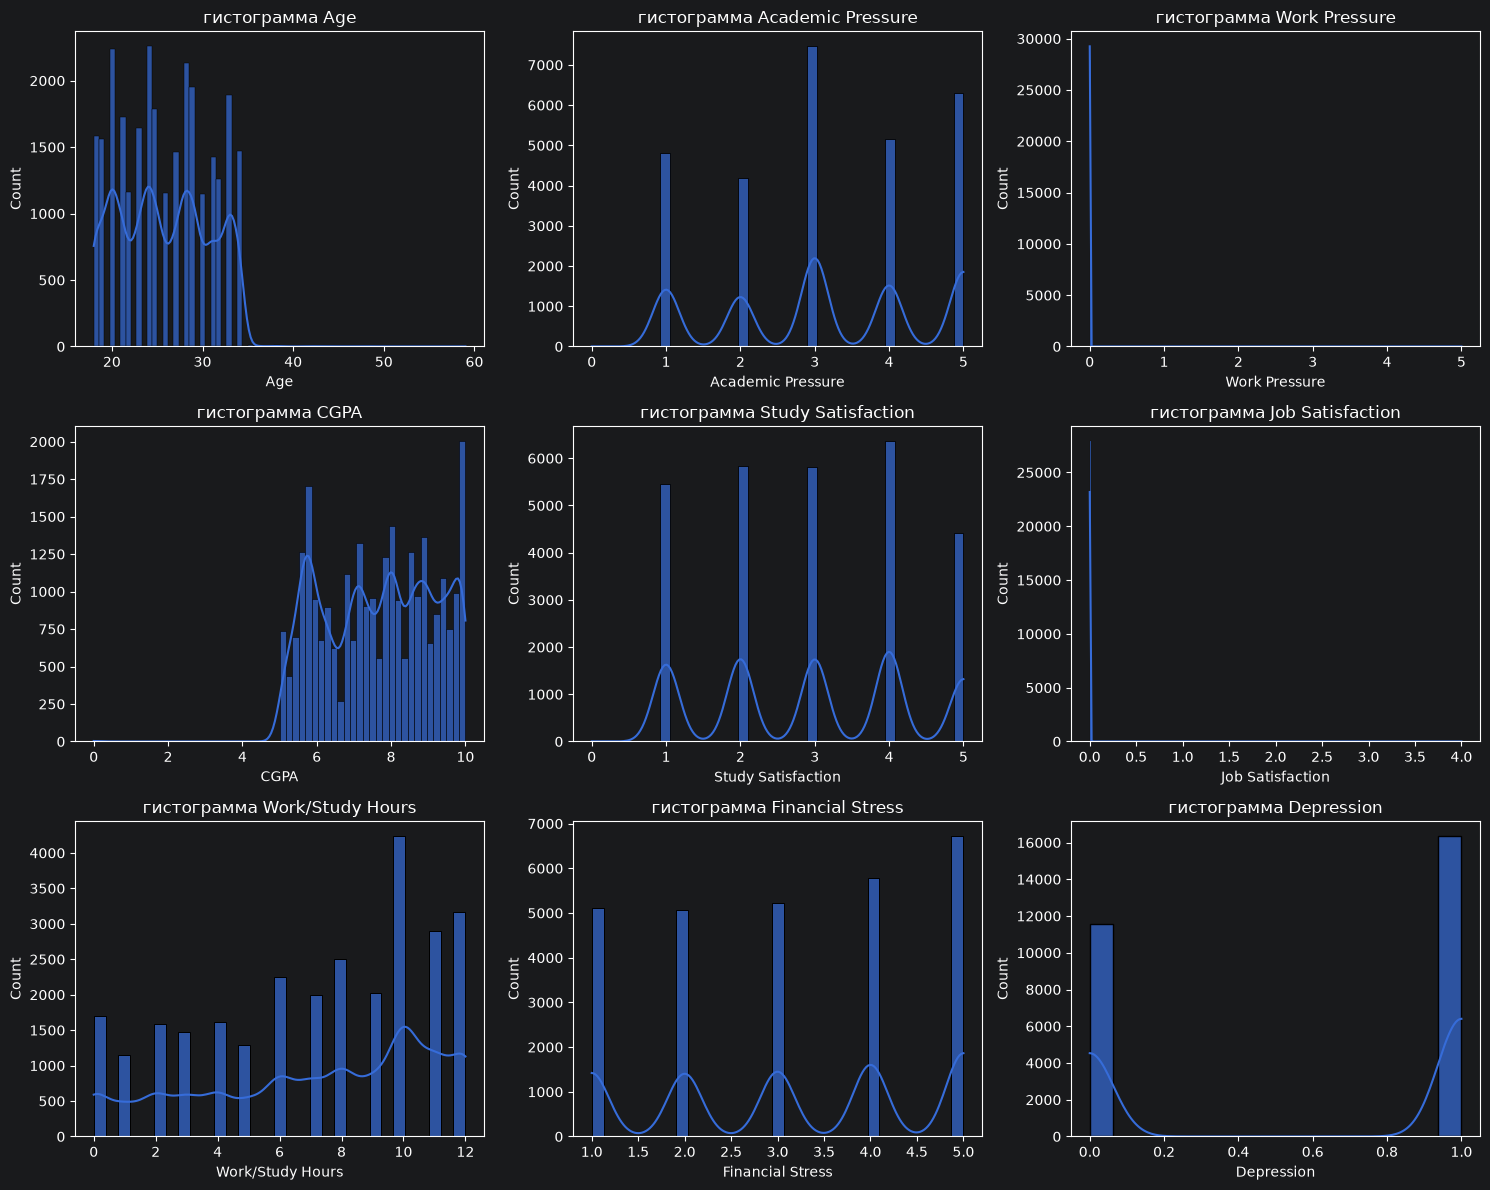

In [118]:
fig, axes = plt.subplots(len(number_columns) // 3, 3, figsize=(15, 4*(len(number_columns) // 3)))
for ax, col in zip(axes.flatten(), number_columns):
    sns.histplot(data=df, x=col, kde=True, ax=ax, alpha=0.7)
    ax.set_title("гистограмма " + col)
plt.tight_layout()
plt.show()

Проанализируй полученные графики и ответь на вопросы.



Age - вполне разумное распределение в основном от 15 до 35 лет

Academic Pressure - дискретная величина, распределена поравну, большинство получают тройки)

Work Pressure - в основном все отвечают 0, но есть и человек который ответил 5.. Сомнительно что все ответили по 0

CGPA - у большинства балл больше 5, а баллы порядка 0 это сомнительные данные

Study Satisfaction - все в основном довольны учебой, выбросов не вижу

Job Satisfaction - скорее всего вся колонка - один большой выброс: ну не могут же все не любить работать да?

Work/Study Hours - все в основном работают/учатся больше 8 часов, да, это многовато. Считаем 0 выбросом (не учатся/не работают)

Financial Stress - распределение дискретное, в основном люди стрессуют

Depression - очень странные данные, не может быть что больше половины людей в датасете с депрессией. Либо очень специфический датасет, либо очень испорченный


### Шаг 2 [0,5 балла]
Построй рядом две столбчатые диаграммы для категориального признака `Sleep Duration`.
  * Слева покажи количество наблюдений в каждой категории продолжительности сна.
  * Справа покажи доли `Depression = 0` и `Depression = 1` внутри каждой категории сна; сумма долей в каждой категории должна быть равна 100%.
  * Для каждой диаграммы упорядочи столбцы от минимальной продолжительности сна до максимальной. Категорию `Others` помести в начало или конец.

  Что можно сказать по полученным графикам?

<Axes: xlabel='Sleep Duration'>

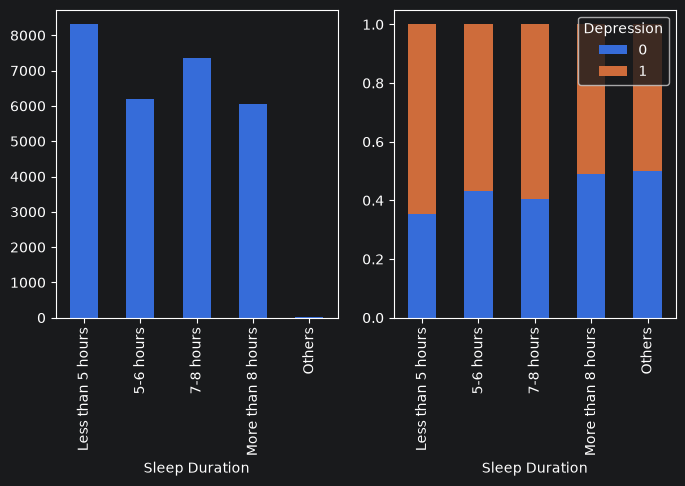

In [119]:
# Напиши код здесь
sleep_durations = df['Sleep Duration'].unique()
sleep_durations[0], sleep_durations[1] = sleep_durations[1], sleep_durations[0] # agi is here: надеемся что .unique() выдает всегда одно и тоже
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
df['Sleep Duration'].value_counts().reindex(sleep_durations).plot(kind='bar', ax=ax[0])
pd.crosstab(df['Sleep Duration'], df['Depression'], normalize='index').reindex(sleep_durations).plot(kind='bar', ax=ax[1], stacked=True)


Проанализируй полученные графики.



### Шаг 3 [0,5 балла]


Построй корреляционную матрицу. Выбери две самые сильные корреляции (по модулю) и попробуй объяснить возможные причины этих связей. Перед интерпретацией проверь распределение признаков и число ненулевых значений.

<Axes: >

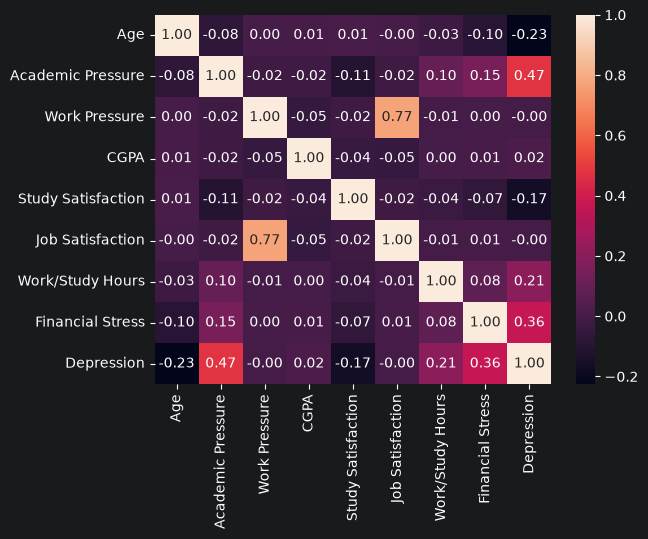

In [120]:
# Напиши код здесь
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    fmt=".2f",
    annot=True,
)


Проанализируй корреляционные матрицы.

Вижу очень сильную корреляцию между Depression и Academic Pressure. Как будто бы очевидно, задавленные студенты очень часто депрессуют
Вижу очень сильную корреляцию между Job Satisfaction и Work Pressure. Очень неочевидная корреляция, чем больше на человека давят, тем больше он доволен работой


## Задание 5 [3 балла]

В этой задаче нужно обучить **логистическую регрессию** и сравнить её с простым baseline — константным предсказанием самого частого класса. Подробнее про нее мы еще поговорим.

Логистическая регрессия сначала считает линейный скор

$$z = b + w_1x_1 + w_2x_2 + \ldots + w_dx_d,$$

а затем пропускает его через сигмоиду:

$$\sigma(z) = \frac{1}{1 + e^{-z}}.$$

По устройству это похоже на линейную модель с дополнительной функцией активации. Сигмоида взаимно однозначно переводит любое значение из $\mathbb{R}$ в интервал $(0; 1)$, поэтому результат можно интерпретировать как вероятность класса 1. При пороге 0,5 модель выдаёт итоговый класс 0 или 1.

В рамках этого задания обучай модель и считай Accuracy **на всей выборке**.

### Шаг 1. Нарисуй сигмоиду [0,5 балла]

Построй график $\sigma(z)$ для значений $z$ от −8 до 8. Подпиши оси, отметь точку $(0; 0{,}5)$ и покажи, что значения функции лежат между 0 и 1.


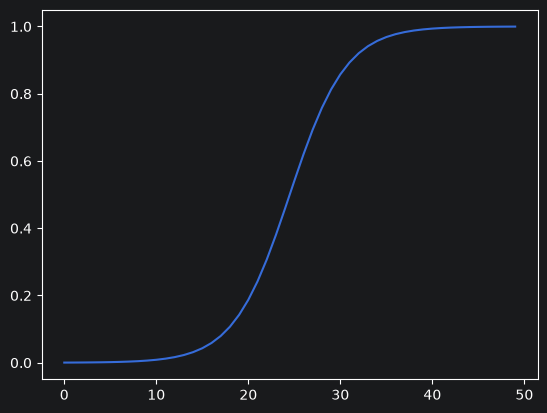

In [121]:
# Построй график сигмоиды

# Напиши код здесь
def sigma(z):
    return 1 / (1 + np.exp(-z))

plt.plot(sigma(np.linspace(-8, 8)))


### Шаг 2. Подготовь данные [0,75 балла]

1. Отдели `Depression` от признаков.
2. Найди числовые и категориальные столбцы.
3. Пропуски в числовых признаках заполни медианой, а числовые признаки масштабируй.
4. Категориальные признаки преобразуй с помощью One-Hot Encoding.
5. Обязательно выведи, сколько признаков было до обработки и сколько стало после One-Hot Encoding.


In [123]:
# Подготовь X и y, затем настрой и выполни предобработку

# Напиши код здесь
x = df.drop(columns="Depression")
y = df["Depression"]
number_columns = x.select_dtypes(include='number').columns
non_number_columns = x.select_dtypes(exclude='number').columns


In [124]:

from sklearn.preprocessing import StandardScaler, MinMaxScaler

for column in number_columns:
    median = x[column].median()
    x[column] = x[column].fillna(median)

    mean = x[column].mean()
    std = x[column].std()

    x[column] = (x[column] - mean) / std
x.head()


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
id,,,,,,,,,,,,,,,,
2,Male,1.463138,Visakhapatnam,Student,1.345518,-0.009777,0.893377,-0.693413,-0.015339,5-6 hours,Healthy,B.Pharm,Yes,-1.121193,-1.488830,No
8,Female,-0.371467,Bangalore,Student,-0.826089,-0.009777,-1.194054,1.510609,-0.015339,5-6 hours,Moderate,BSc,No,-1.121193,-0.793067,Yes
26,Male,1.055448,Srinagar,Student,-0.102220,-0.009777,-0.425716,1.510609,-0.015339,Less than 5 hours,Healthy,BA,No,0.497086,-1.488830,Yes
30,Female,0.443913,Varanasi,Student,-0.102220,-0.009777,-1.404837,-0.693413,-0.015339,7-8 hours,Moderate,BCA,Yes,-0.851480,1.294223,Yes
32,Female,-0.167622,Jaipur,Student,0.621649,-0.009777,0.322223,0.041261,-0.015339,5-6 hours,Moderate,M.Tech,Yes,-1.660620,-1.488830,No


In [125]:

df_en = pd.get_dummies(x, columns=non_number_columns, drop_first=True)
df_en.head()


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Gender_Male,City_Agra,...,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
id,,,,,,,,,,,,,,,,,,,,,
2,1.463138,1.345518,-0.009777,0.893377,-0.693413,-0.015339,-1.121193,-1.488830,True,False,...,False,False,False,False,False,False,False,False,True,False
8,-0.371467,-0.826089,-0.009777,-1.194054,1.510609,-0.015339,-1.121193,-0.793067,False,False,...,False,False,False,False,False,False,False,False,False,True
26,1.055448,-0.102220,-0.009777,-0.425716,1.510609,-0.015339,0.497086,-1.488830,True,False,...,False,False,False,False,False,False,False,False,False,True
30,0.443913,-0.102220,-0.009777,-1.404837,-0.693413,-0.015339,-0.851480,1.294223,False,False,...,False,False,False,False,False,False,False,False,True,True
32,-0.167622,0.621649,-0.009777,0.322223,0.041261,-0.015339,-1.660620,-1.488830,False,False,...,False,False,False,False,False,False,False,False,True,False


In [126]:

print('до обработки:', x.shape[1])
print('после обработки:', df_en.shape[1])


до обработки: 16
после обработки: 109


### Шаг 3. Обучи логистическую регрессию [1 балл]

Обучи `LogisticRegression` на всей подготовленной выборке. Получи предсказания для этих же объектов и посчитай `Accuracy`.


In [138]:
# Обучи LogisticRegression и посчитай Accuracy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Напиши код здесь
model = LogisticRegression()
model.fit(df_en, y)
y_pred = model.predict(df_en)
model_mse = mean_squared_error(y, y_pred)
model_mae = mean_absolute_error(y, y_pred)

print(f"{model.__class__.__name__} MSE:  {model_mse:.2f}")
print(f"{model.__class__.__name__} RMSE: {np.sqrt(model_mse):.2f}")
print(f"{model.__class__.__name__} MAE:  {model_mae:.2f}")


LogisticRegression MSE:  0.15
LogisticRegression RMSE: 0.39
LogisticRegression MAE:  0.15


### Шаг 4. Сравни модель с baseline [0,75 балла]

Создай `DummyClassifier(strategy='most_frequent')`. Такая модель игнорирует признаки и всегда предсказывает самый частый класс. Сравни её Accuracy с логистической регрессией в таблице или на графике и напиши короткий вывод.


In [139]:
# Обучи DummyClassifier и сравни результаты двух моделей
from sklearn.dummy import DummyClassifier

# Напиши код здесь
model = DummyClassifier(strategy='most_frequent')
model.fit(df_en, y)
y_pred = model.predict(df_en)
model_mse = mean_squared_error(y, y_pred)
model_mae = mean_absolute_error(y, y_pred)

print(f"{model.__class__.__name__} MSE:  {model_mse:.2f}")
print(f"{model.__class__.__name__} RMSE: {np.sqrt(model_mse):.2f}")
print(f"{model.__class__.__name__} MAE:  {model_mae:.2f}")


DummyClassifier MSE:  0.41
DummyClassifier RMSE: 0.64
DummyClassifier MAE:  0.41


Напиши вывод: насколько логистическая регрессия лучше константного baseline и что ограничивает такое сравнение.


Логистическая регрессия сильно лучше(на 63.9%) простого константного "У тебя депрессия)"